This file uses data from : https://open.toronto.ca/dataset/police-annual-statistical-report-reported-crimes/
to create a visualization showing the trend in crimes against person and crimes against property.
One static and one interactive visualization has been created.

In [7]:
#Loading relevant libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import pandas as pd
import plotly.express as px

import os

In [31]:
#Setting directory

os.chdir("/Users/Bisma/Dropbox/visualization")


# Load your dataset
df = pd.read_csv("ReportedCrimes.csv")

#filtering by crime against person and crimeagainst property 

filtered_df = df[df['CATEGORY'].isin(["Crimes Against Property", "Crimes Against the Person"])]

# Preview
print(filtered_df.head())



   _id  REPORT_YEAR DIVISION                   CATEGORY  \
0    1         2022      D32    Crimes Against Property   
1    2         2023      D12    Crimes Against Property   
2    3         2014      D13    Crimes Against Property   
3    4         2021      NSA  Crimes Against the Person   
4    5         2020      D53    Crimes Against Property   

                   SUBTYPE  COUNT_  COUNT_CLEARED  
0               Auto Theft      79              0  
1      Break & Enter-House       1              0  
2               Auto Theft       7              0  
3         Sexual Violation       1              0  
4  Break & Enter-Apartment       2              0  


In [33]:
# Group by Division and Year, summing crime counts
cat_year_trends = filtered_df.groupby(['CATEGORY', 'REPORT_YEAR'])['COUNT_'].sum().reset_index()

# Reshaping data for plotting
trend_pivot = cat_year_trends.pivot(index='REPORT_YEAR', columns='CATEGORY', values='COUNT_')
print(trend_pivot.head())


CATEGORY     Crimes Against Property  Crimes Against the Person
REPORT_YEAR                                                    
2014                           68793                      25339
2015                           69628                      26876
2016                           73835                      27308
2017                           80095                      28161
2018                           92993                      28807


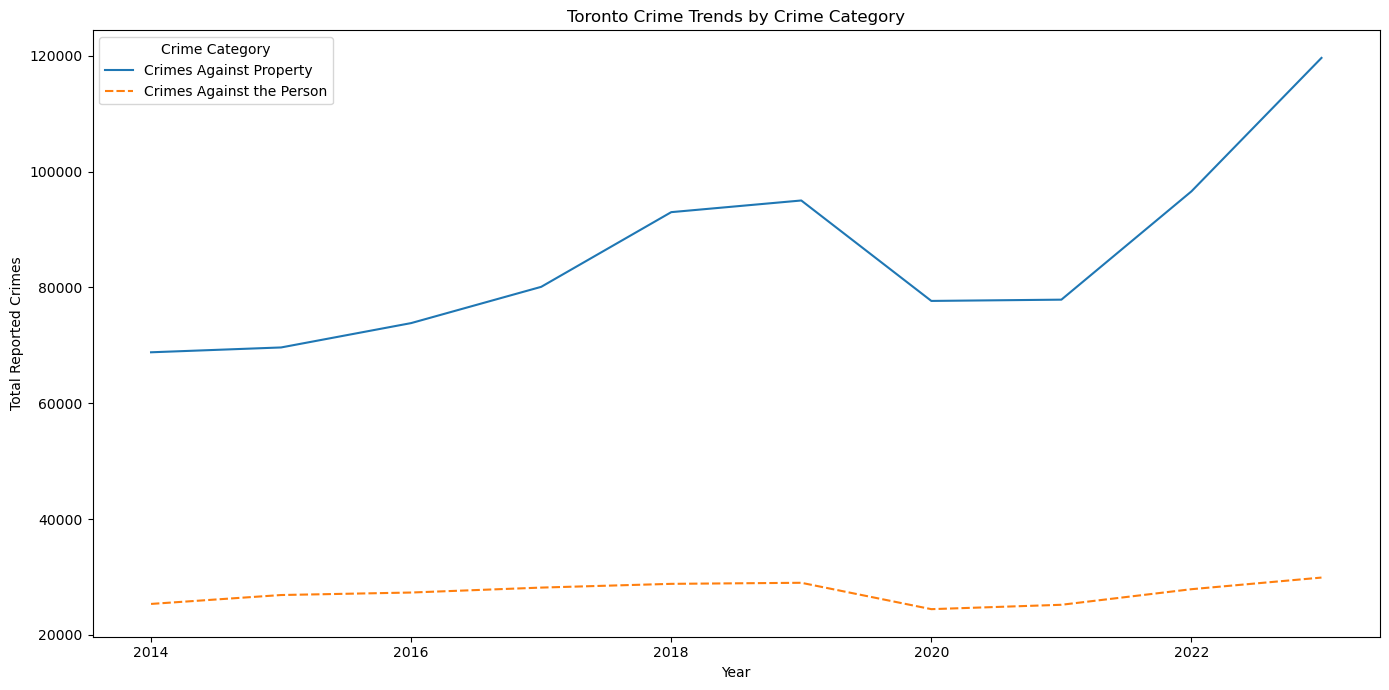

In [ ]:
# static plot showing trend in crimes against property and crimes against person

plt.figure(figsize=(14, 7))
sns.lineplot(data=trend_pivot)
plt.title('Toronto Crime Trends by Crime Category')
plt.xlabel('Year')
plt.ylabel('Total Reported Crimes')
plt.legend(title='Crime Category')
plt.tight_layout()


plt.show()


In [ ]:
#Interactive graph showing trends in crimes against property and crimes against person.


summary = filtered_df.groupby(['REPORT_YEAR', 'CATEGORY'])['COUNT_'].sum().reset_index()




fig = px.line(summary,
              x='REPORT_YEAR',
              y='COUNT_',
              color='CATEGORY',
              markers=True,
              title='Crime Trends in Toronto by Category',
              labels={
                  'REPORT_YEAR': 'Year',
                  'COUNT_': 'Total Crimes',
                  'CATEGORY': 'Category'
              })

fig.update_layout(template='plotly_white',
                  hovermode='x unified',
                  legend_title_text='Crime Category',
                  width=1000,
                  height=600)


fig.update_layout(
    title={
        'text': 'Crime Trends in Toronto',
        'x': 0.5,  # center the title
        'xanchor': 'center',
        'font': {
            'size': 30,        # change title font size
            'color': 'black',  # optional
            'family': 'Arial'  # optional
        }
    }
)

fig.show()

